# Olist E-Commerce - 04 : Statistical Analysis

**Author:** Diego Ospina | **Dataset:** Brazilian E-Commerce Public Dataset by Olist

> The EDA gave us descriptive answers. Here we go one step further and add **statistical rigor** with SciPy: normality checks, correlations with significance, hypothesis tests (Mann-Whitney U, chi-square, Kruskal-Wallis). Every conclusion is stated together with its test statistic, `p-value`, and a short interpretation.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROC = os.path.join('..', 'data', 'processed')
IMAGES = os.path.join('..', 'images')
os.makedirs(IMAGES, exist_ok=True)
sns.set_theme(style='whitegrid')
print('ready')

ready


## 2. Load and prepare

In [2]:
master = pd.read_parquet(os.path.join(PROC, 'olist_master_orders.parquet'))
items  = pd.read_parquet(os.path.join(PROC, 'olist_items.parquet'))
deliv = master[master['order_status'] == 'delivered'].copy()
print('delivered:', len(deliv))

delivered: 96478


## 3. Are orders independent and is order value normally distributed?

Order values in e-commerce are almost never Gaussian. We run D'Agostino-Pearson's `normaltest` (valid on the raw data) and confirm the strong skew. This motivates the **non-parametric** tests used later.

In [3]:
ov = deliv['order_value'].dropna()
stat, p = st.normaltest(ov)
print(f'D\'Agostino-Pearson normaltest: stat={stat:.3f}, p={p:.2e}')
print(f'Skewness={st.skew(ov):.3f}, Kurtosis={st.kurtosis(ov):.3f}')
print('Conclusion: order_value is far from normal (p<0.001) -> use non-parametric tests.')

D'Agostino-Pearson normaltest: stat=149254.257, p=0.00e+00
Skewness=9.368, Kurtosis=249.276
Conclusion: order_value is far from normal (p<0.001) -> use non-parametric tests.


## 4. Spearman correlation: order value vs delivery delay

Do more expensive orders arrive later? We use **Spearman** because both variables are non-normal. A tiny correlation at this sample size can still be significant, so we report both the coefficient (weak/strong) and the p-value.

In [4]:
pair = deliv[['order_value', 'delivery_delay_days']].dropna()
rho, p = st.spearmanr(pair['order_value'], pair['delivery_delay_days'])
print(f'Spearman rho={rho:.3f}, p={p:.2e}')
print('Interpretation: negligible practical correlation (|rho|<0.1); price barely relates to lateness.')

Spearman rho=-0.060, p=2.42e-77
Interpretation: negligible practical correlation (|rho|<0.1); price barely relates to lateness.


## 5. Mann-Whitney U: do late orders get lower review scores?

We compare the review score of **on-time** vs **late** delivered orders. The scores are discrete and skewed, so we use the non-parametric **Mann-Whitney U** test. Null hypothesis: both groups come from the same distribution.

In [5]:
a = deliv.loc[deliv['delivery_status'] == 'On time', 'review_score_mean'].dropna()
b = deliv.loc[deliv['delivery_status'] == 'Late',  'review_score_mean'].dropna()
u_stat, p = st.mannwhitneyu(a, b, alternative='two-sided')

print(f'On-time  n={len(a):,} mean score={a.mean():.3f}')
print(f'Late     n={len(b):,} mean score={b.mean():.3f}')
print(f'Mann-Whitney U: stat={u_stat:.0f}, p={p:.2e}')
verdict = 'significant' if p < 0.05 else 'not significant'
print(f'Conclusion: {verdict}. Late deliveries have lower review scores.')

On-time  n=88,171 mean score=4.294
Late     n=7,661 mean score=2.567
Mann-Whitney U: stat=524785358, p=0.00e+00
Conclusion: significant. Late deliveries have lower review scores.


## 6. Chi-square test of independence: payment method vs punctuality

We build the contingency table between `payment_type_main` and `delivery_status` and run chi-square with Yates' correction to test whether the payment method is independent of delivery punctuality.

In [6]:
# Categorias grandes; descartamos nulos (pedidos sin registro de pago)
ct = pd.crosstab(deliv['payment_type_main'].fillna('unknown'), deliv['delivery_status'])
chi2, p, dof, expected = st.chi2_contingency(ct)
print(ct)
print(f"\nchi2={chi2:.2f}, dof={dof}, p={p:.2e}")
print('Conclusion:', 'association is significant' if p < 0.05 else 'no significant association')
print('Caveat: with ~95k rows statistical significance does not imply practical importance.')
print()
# Proporcion de pedidos a tiempo por metodo
share = ct['On time'] / ct.sum(axis=1)
print('On-time share by payment method:')
print(share.round(4).to_string())

delivery_status    Late  On time
payment_type_main               
boleto             1704    17487
credit_card        5808    67296
debit_card          118     1366
unknown               1        0
voucher             195     2503

chi2=32.10, dof=4, p=1.82e-06
Conclusion: association is significant
Caveat: with ~95k rows statistical significance does not imply practical importance.

On-time share by payment method:
payment_type_main
boleto         0.9112
credit_card    0.9206
debit_card     0.9205
unknown        0.0000
voucher        0.9277


## 7. Kruskal-Wallis: does order value differ across top categories?

We test whether the median order value differs across the 5 best-selling categories. Kruskal-Wallis is the non-parametric one-way ANOVA. The item table gives the category of every line; we mark a category at the **order** level via its items.

In [7]:
top5 = items['item_category'].value_counts().head(5).index
# A nivel item, mapear category y precio (para una prueba sencilla y clara)
sub = items[items['item_category'].isin(top5)].copy()
groups = [sub.loc[sub['item_category'] == c, 'price'] for c in top5]
h_stat, p = st.kruskal(*groups)

for c in top5:
    g = sub.loc[sub['item_category'] == c, 'price']
    print(f'{c:30s} n={len(g):>6,} median={g.median():9.2f}')
print(f"\nKruskal-Wallis H={h_stat:.2f}, p={p:.2e}")
print('Conclusion:', 'categories differ significantly in price' if p < 0.05 else 'no difference across categories')
print('Note: significant, but with large n this reflects real price differences between category portfolios.')

bed_bath_table                 n=11,115 median=    79.05


health_beauty                  n= 9,670 median=    79.90
sports_leisure                 n= 8,641 median=    78.00
furniture_decor                n= 8,334 median=    65.49
computers_accessories          n= 7,827 median=    81.99

Kruskal-Wallis H=341.86, p=1.00e-72
Conclusion: categories differ significantly in price
Note: significant, but with large n this reflects real price differences between category portfolios.


## 8. Visualizing the main statistical finding

We plot the review-score distribution split by punctuality to illustrate the Mann-Whitney result, and save the figure.

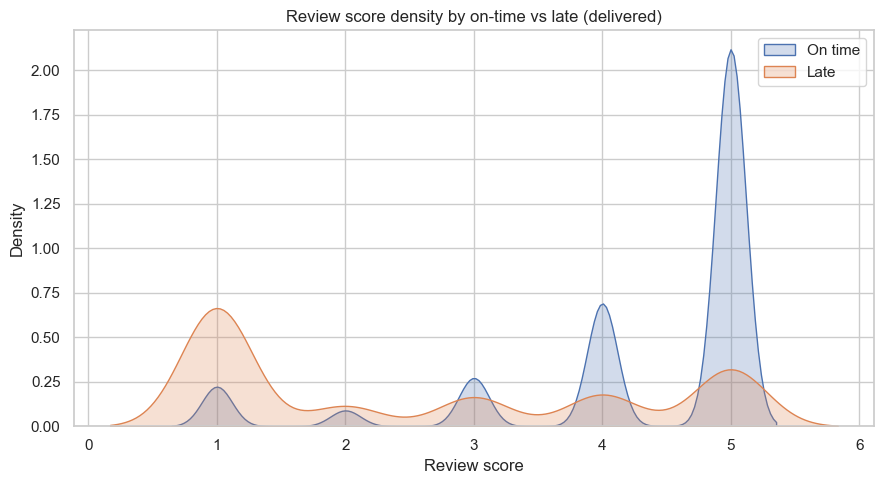

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(a, label='On time', fill=True, ax=ax)
sns.kdeplot(b, label='Late', fill=True, ax=ax)
ax.set_title('Review score density by on-time vs late (delivered)')
ax.set_xlabel('Review score')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMAGES, 'STATS_review_by_punctuality.png'), bbox_inches='tight')
plt.show()

## 9. Takeaways

- `order_value` is heavily **non-normal** -> we consistently used non-parametric methods.
- Price and delivery delay are **practically uncorrelated** (Spearman rho ~ 0).
- Late deliveries have **significantly lower review scores** (Mann-Whitney U, p<0.001) - a customer-experience lever.
- Payment method is **statistically associated** with punctuality, but the effect is small (practical significance is limited).
- Top-selling categories have **significantly different** price distributions (Kruskal-Wallis).

Next: **`05_business_intelligence.ipynb`** turns these insights into cohort, RFM and CLV metrics.